<a href="https://colab.research.google.com/github/hudamohmand/undergrad_ml_assignments/blob/main/generallinearmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##6: General Linear Models

**Question 1:**
1) The reason we use these models instead of linear models is because when analyzing the relationship is not always linear. Using a linear model will not provide the best predictions or probabilities. Using these other models however, provide simple nonlinear outputs making them more useful for analysis.

2) Binary and categorical cross entropy are effective because they help with identifying how close a model's predicted probability is to the actual probability. In other words, its a way to check and be confident in the correct answer.

3) It is true that logistic regression is a linear model because it outputs a linear combination of the features you input into it.

4) False, you can use logistic regression for classification, it provides probabilities that can be utilized for classification.

5) No it does not, instead it represents the average change in the log odds.

6) False, it can still help showcase how accurate the predictions are.

7) False, you can not confidently say to 'always use' logistic regression instead, because it depends on the problem.

**Question 2:**

In [1]:
#q2 part 1

import pandas as pd

df = pd.read_csv('data.csv', sep=';')

df = df[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment',
         'Curricular units 1st sem (approved)',
         'Target']]

In [2]:
df.isnull().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


- There were no missing values, therefore no additional cleaning is needed.

In [4]:
df['Dropout'] = df['Target'].apply(
    lambda x: 1 if x == 'Dropout' else 0
)

In [6]:
#q2 part 2
from sklearn.linear_model import LogisticRegression

X = df[['Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'Age at enrollment']]

y = df['Dropout']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

Debtor 0.5306254196925666
Tuition fees up to date -2.55654243281313
Scholarship holder -1.227441522252298
Age at enrollment 0.04992541246433546


- The variables debtor and age at enrollment increase dropout probability, tuition fees up to date and scholarship holder decrease dropout probability. Yes, being up to date on tuition does seem to reduce dropout risk.

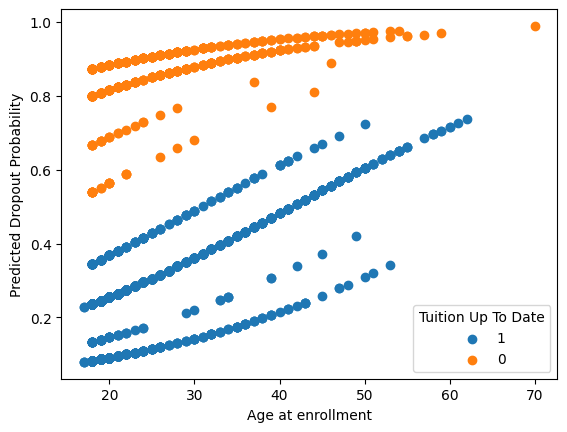

In [11]:
#q2 part 3
probs = model.predict_proba(X)[:, 1]
df['pred_prob'] = probs
import matplotlib.pyplot as plt

for val in df['Tuition fees up to date'].unique():
    subset = df[df['Tuition fees up to date'] == val]
    plt.scatter(subset['Age at enrollment'],
                subset['pred_prob'],
                label=str(val))

plt.xlabel('Age at enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.legend(title='Tuition Up To Date')
plt.show()

Being up to date on tuition lowers fropout probability across ages 20-30 the most.

In [12]:
group_means = df.groupby('Tuition fees up to date')['pred_prob'].mean()
print(group_means)

Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64


Students who are not up to date with their tuition have an average predicted dropout probability of 0.86 compared to the 0.25 of students who do keep up to date with their tuition. It changes the predicted probability of dropouts by about 0.61 which is quite high.

In [13]:
#q2 part 4
from sklearn.metrics import confusion_matrix, accuracy_score

preds = model.predict(X)

cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)

print(cm)
print(acc)

[[2841  162]
 [ 891  530]]
0.7619801084990958


The accuracy of the model is about 0.76.

In [18]:
#q2 part 5

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)
lin_probs[:10]

array([0.26325305, 0.76593188, 0.76593188, 0.26325305, 0.50042896,
       0.63304697, 0.06780739, 0.79439299, 0.0962685 , 0.84162767])

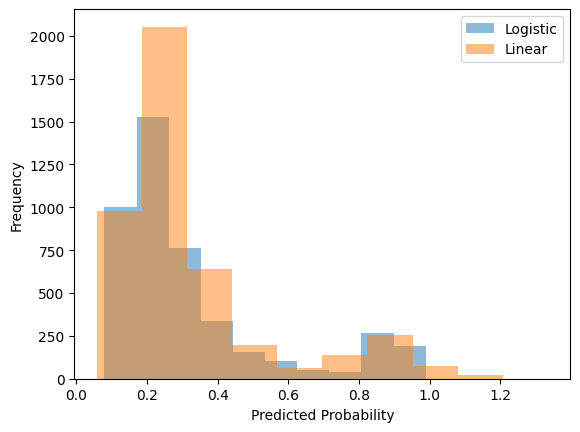

In [17]:
plt.hist(probs, alpha=0.5, label='Logistic')
plt.hist(lin_probs, alpha=0.5, label='Linear')

plt.legend()
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

- The linear model exceeds a probability of 1.0 making logistic regression more reliable for classification in this case.

In [19]:
#q2 part 6

#The students most at risk of dropping out include the students who are in debt and are not up to date with their tuition.
#Some interventions to prevent this include loans, payment plans, or more financial aid.

In [20]:
#q2 part 7
multi_X = df[['Debtor',
              'Tuition fees up to date',
              'Curricular units 1st sem (approved)']]

multi_y = df['Target']

multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi_model.fit(multi_X, multi_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [21]:
multi_preds = multi_model.predict(multi_X)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(multi_y, multi_preds))

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


- All the 0s in the matrix suggest that the model does not do well in distinguishing students who are enrolled from students who have dropped out or have graduated.

In [22]:
multi_probs = multi_model.predict_proba(multi_X)
print(multi_probs[:5])

[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


- The model is capable of predicting probabilites for dropouts, enrolled students and graduated students.

**Question 3:**

In [1]:
#q3 part 1
import pandas as pd

df = pd.read_csv('cirrhosis.csv')

df = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]

In [2]:
df.isnull().sum()

,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


- The variables 'drug' and 'stage' appear to have missing values, so to clean the data, I will drop the rows with missing values using dropna().

In [3]:
df = df.dropna()

In [4]:
df['Survived'] = df['Status'].apply(
    lambda x: 1 if x in ['C', 'CL'] else 0
)

In [11]:
#q3 part 2
from sklearn.linear_model import LogisticRegression

X = df[['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo']]
y = df['Survived']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
for name, coef in zip(X.columns, model.coef_[0]):
    print(name, coef)

Bilirubin -0.35142389843544086
Edema_S -0.45067663255235757
Edema_Y -1.6110491833168035
Drug_Placebo 0.23122512449170882


- Drug_Placebo is the only variable that improves survival probability. A higher bilirubin predicts a lower survival rate. Edema_S is a bit more mild compared to Edema_Y.

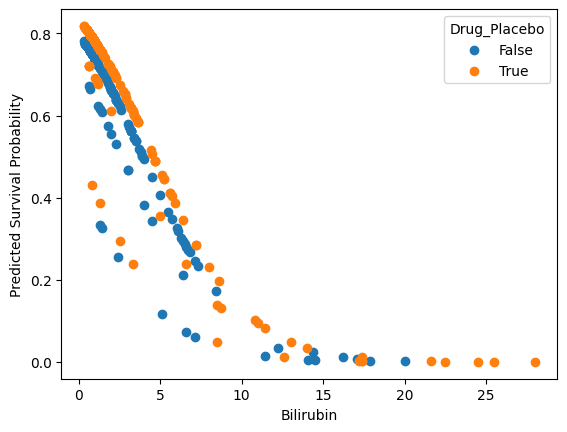

In [12]:
#q3 part 3
probs = model.predict_proba(X)[:, 1]
df['pred_prob'] = probs
import matplotlib.pyplot as plt

for val in df['Drug_Placebo'].unique():
    subset = df[df['Drug_Placebo'] == val]
    plt.scatter(subset['Bilirubin'],
                subset['pred_prob'],
                label=str(val))

plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.legend(title='Drug_Placebo')
plt.show()

- Patients recieving the placebo tend to have a higher predicted survival probability.

In [13]:
group_means = df.groupby('Drug_Placebo')['pred_prob'].mean()
print(group_means)

Drug_Placebo
False    0.590054
True     0.608902
Name: pred_prob, dtype: float64


 - The drug does not change the survival probability by a lot, patients who recieve it only have an increased survival probability by about 0.01.

In [14]:
#q3 part 4
from sklearn.metrics import confusion_matrix, accuracy_score

preds = model.predict(X)

cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)

print(cm)
print(acc)

[[ 59  66]
 [ 16 171]]
0.7371794871794872


- The model has an accuracy of about 74%. 59 represents those who did not survive, 66 represents the predicted would survive but did not, 16 represents those predicted not to survive but actually did, and lastly 171 is those correctly predicted to survive.

In [16]:
#q3 part 5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

lin_probs = lin_model.predict(X)
lin_probs[:10]

array([-0.17983881,  0.69197404,  0.56137328,  0.54574625,  0.65275848,
        0.75433423,  0.74652071,  0.77386803,  0.60993209, -0.05497048])

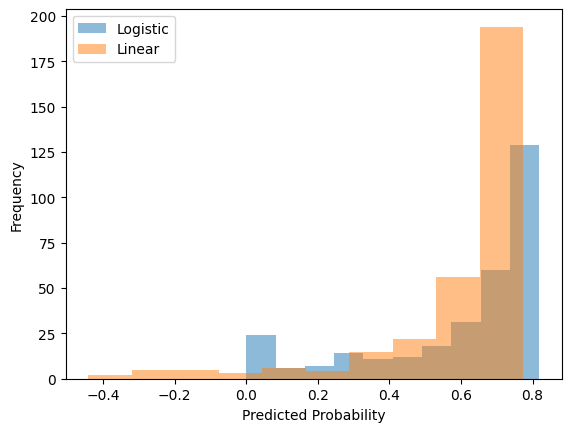

In [17]:
plt.hist(probs, alpha=0.5, label='Logistic')
plt.hist(lin_probs, alpha=0.5, label='Linear')

plt.legend()
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

- Logistic regression keeps the outputs less complex compared to the linear so it may be more appropriate for this case.

In [18]:
#q3 part 6
stage_X = df[['Bilirubin', 'Edema_S', 'Edema_Y']]
stage_y = df['Stage']

stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(stage_X, stage_y)

LogisticRegression(max_iter=1000)

In [19]:
stage_preds = stage_model.predict(stage_X)

from sklearn.metrics import confusion_matrix
print(confusion_matrix(stage_y, stage_preds))

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]


- Stage 1 and Stage 2 are not predicted as there are no observations for those categories. The model performs well for stages 3 and 4 nevertheless, but this does indicate bias.

In [20]:
stage_probs = stage_model.predict_proba(stage_X)
print(stage_probs[:5])

[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


- These values explain why the confusion matrix does not predict for earlier stages, its because the predicted probabilties for those stages are very low, so the model favors the later stages.

**Question 4: All Parts**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
img = Image.open("/content/drive/MyDrive/hw6.jpeg")

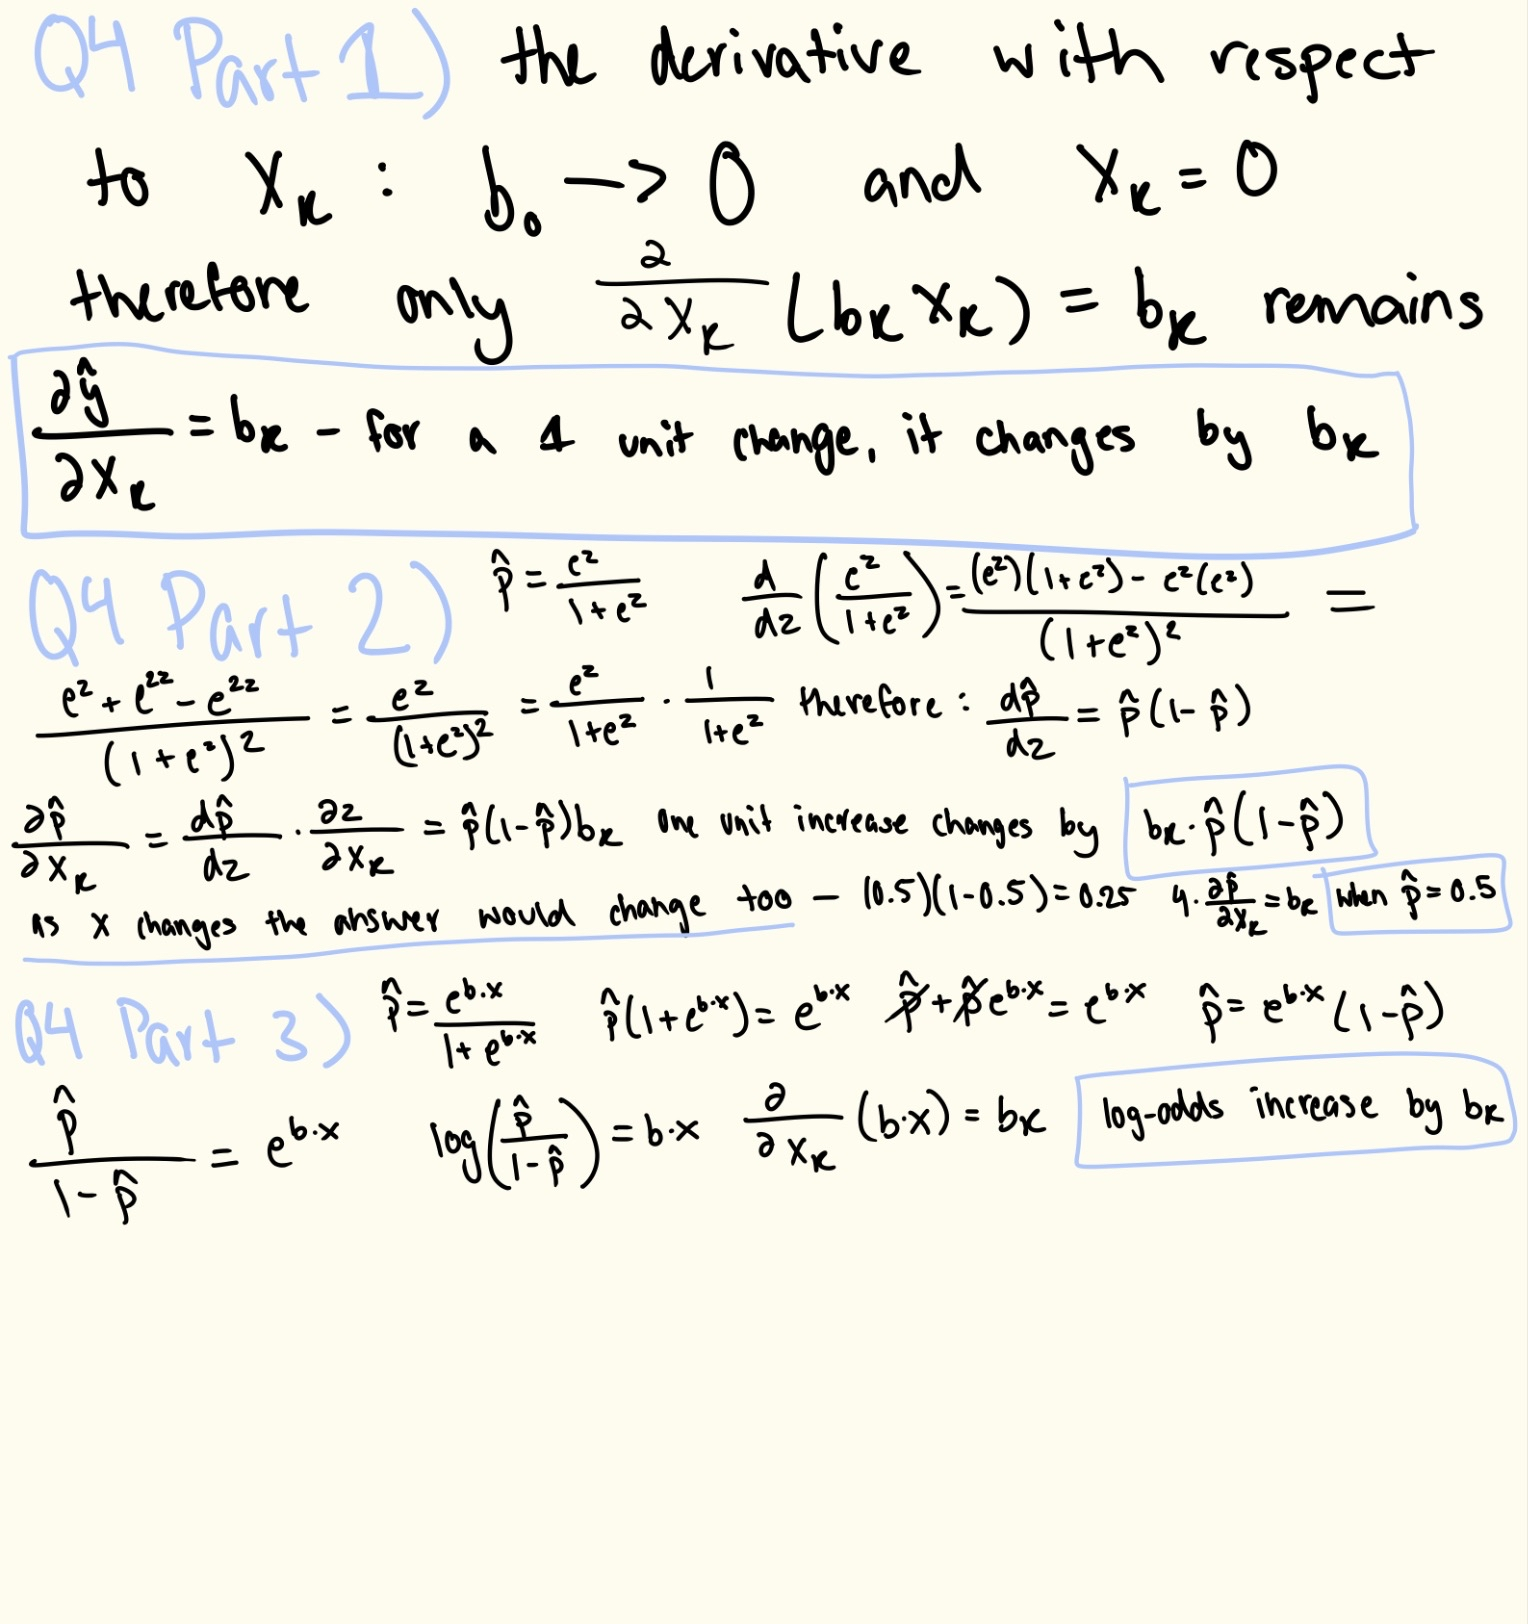

In [25]:
from IPython.display import display
from PIL import Image

display(Image.open("hw6.jpeg"))